
=== Processing 260716-07(NCF6)-A017.txt ===
Year =  2026.0
Month =  7.0
Day =  16.0
Latitude (degs N) =  34.31649
Longitude (degs E) =  -77.95383
Secchi depth (cm) =  9999.0
Forel Ule =  99.0
pH =  99.0


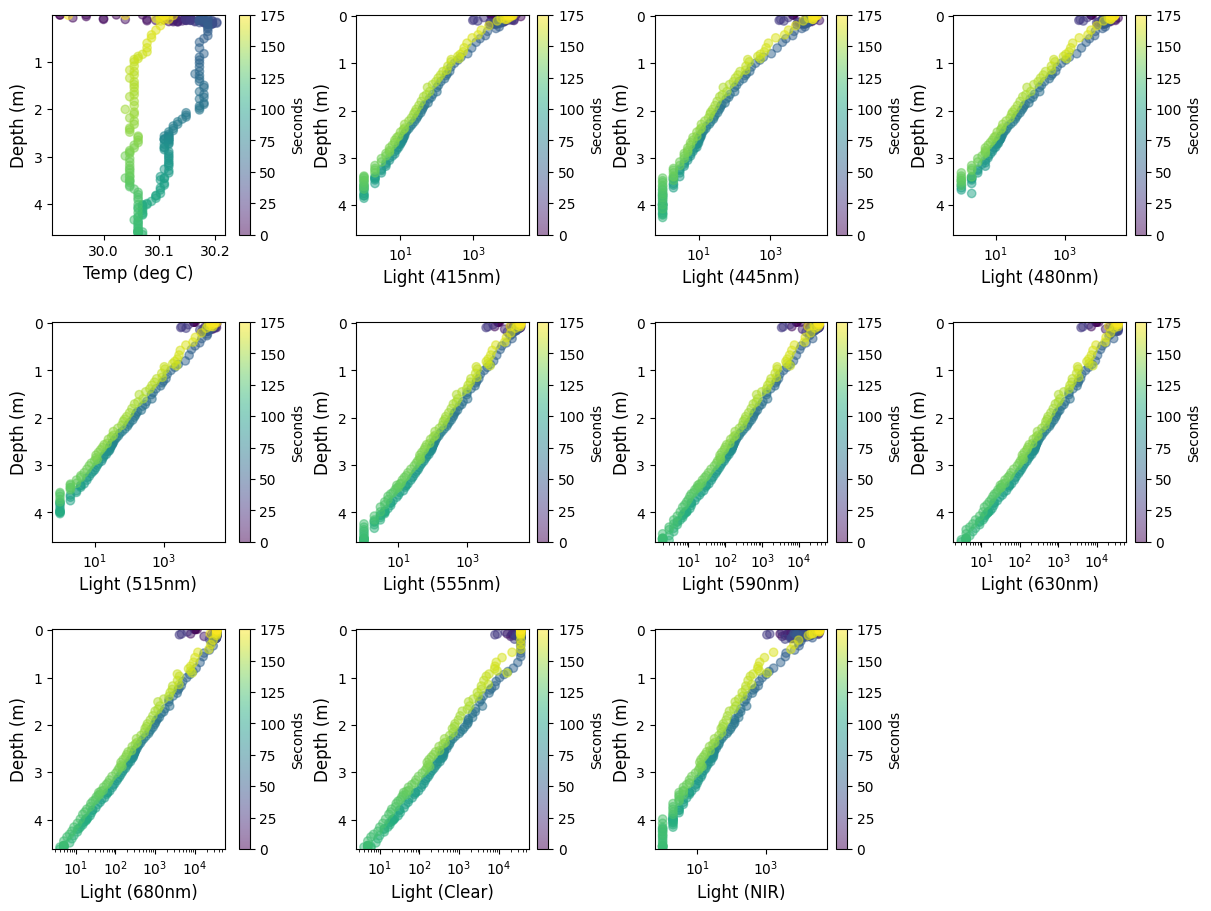

In [16]:
# Programs and functions
from calendar import Day, Month

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import datetime
import linecache
import re
from matplotlib import pyplot as plt 
from pathlib import Path

from scipy.stats import linregress

# 06/03
# Datafiles
data_dir = Path.cwd().parent / "CFRE"
files = [
    data_dir / "260716-07(NCF6)-A017.txt",
]


# Function to process a single SSD file
def process_file(filepath):
#Extract from file: Secchi Depth (SD), Forel–Ule (FU), 
#pH, serial number of device (SN), latitude, longitude and date
    filepath_str = str(filepath)
    SD = linecache.getline(filepath_str, 1)
    SD = float(re.findall(r'\d+', SD)[0]) if re.findall(r'\d+', SD) else 0.0
    FU = linecache.getline(filepath_str, 2)
    FU = float(re.findall(r'\d+', FU)[0]) if re.findall(r'\d+', FU) else 0.0
    pH = linecache.getline(filepath_str, 3)
    pH = float(re.findall(r'\d+', pH)[0]) if re.findall(r'\d+', pH) else 0.0
    SN = linecache.getline(filepath_str, 4)
    SN = float(re.findall(r'\d+', SN)[0]) if re.findall(r'\d+', SN) else 0.0
    Latitude = linecache.getline(filepath_str, 5)
    Latitude = float(re.findall(r'-?\d+\.?\d+', Latitude)[0]) if re.findall(r'-?\d+\.?\d+', Latitude) else 0.0
    Longitude = linecache.getline(filepath_str, 6)
    Longitude = float(re.findall(r'-?\d+\.?\d+', Longitude)[0]) if re.findall(r'-?\d+\.?\d+', Longitude) else 0.0
    Date = linecache.getline(filepath_str, 7)
    Date = re.findall(r'\d+', Date)
    Year = float(Date[0]) if len(Date) > 0 else 0.0
    Month = float(Date[1]) if len(Date) > 1 else 0.0
    Day = float(Date[2]) if len(Date) > 2 else 0.0

    #Extract profile data
    df = pd.read_csv(filepath_str, header=7)
    Time_SS = df.loc[:,'Time (UTC)'].to_numpy()
    Pressure_SS = df.loc[:,' Pressure (mbar) MS5803'].to_numpy()
    Temp_MS5803_SS = df.loc[:,' Temp (deg C) MS5803'].to_numpy()
    E415nm_SS = df.loc[:,' ED 415nm'].to_numpy()
    E445nm_SS = df.loc[:,' ED 445nm'].to_numpy()
    E480nm_SS = df.loc[:,' ED 480nm'].to_numpy()
    E515nm_SS = df.loc[:,' ED 515nm'].to_numpy()
    E555nm_SS = df.loc[:,' ED 555nm'].to_numpy()
    E590nm_SS = df.loc[:,' ED 590nm'].to_numpy()
    E630nm_SS = df.loc[:,' ED 630nm'].to_numpy()
    E680nm_SS = df.loc[:,' ED 680nm'].to_numpy()
    EPAR_SS = df.loc[:,' ED Clear'].to_numpy()
    ENIR_SS = df.loc[:,' ED NIR'].to_numpy()
    Temp_TH_SS = df.loc[:,' Temp (deg C) TMP117'].to_numpy()
    
    #Compute atmospheric pressure assuming first 5 readings are in atmosphere
    ATMOS_P = np.median(Pressure_SS[0:5])

    #Correct differences in sensor distance
    #Compute depth (assuming pressure = depth)
    Depth_SS = ((Pressure_SS - ATMOS_P)/100.)
    #Correct for distance between temperature sensor and pressure sensor
    Depth_SS_T = Depth_SS + 0.007
    #Correct for distance between light sensor and pressure sensor
    Depth_SS_L = Depth_SS - 0.02
    
    #Sort time to decimal hour and compute seconds (DATA_SEC) and second since start (DATA_SEC0)
    HH = np.empty([len(Time_SS)])
    MM = np.empty([len(Time_SS)])
    SS = np.empty([len(Time_SS)])
    for j in range(len(Time_SS)):
        time = datetime.datetime.strptime(Time_SS[j], '%H:%M:%S')
        HH[j] = time.hour
        MM[j] = time.minute
        SS[j] = time.second
    DATA_SEC = (HH*3600.) + (MM*60.) + (SS)
    DATA_SEC0 = DATA_SEC - DATA_SEC[0]

    #Print extracted data
    print('Year = ', Year)
    print('Month = ', Month)
    print('Day = ', Day)
    print('Latitude (degs N) = ', Latitude)
    print('Longitude (degs E) = ', Longitude)
    print('Secchi depth (cm) = ', SD)
    print('Forel Ule = ', FU)
    print('pH = ', pH)
    
    # Return a dictionary containing station metadata and all profile/irradiance data
    return {
        # File identifier and environmental metadata (depth, color, pH, location, date)
        'filename': filepath.name, 'metadata': {'SD': SD, 'FU': FU, 'pH': pH, 'Latitude': Latitude, 'Longitude': Longitude, 'Year': Year, 'Month': Month, 'Day': Day},
        # Time and depth arrays: uncorrected (SS), temperature-corrected (T), light-corrected (L), and normalized time (0)
        'Time_SS': Time_SS, 'Depth_SS_T': Depth_SS_T, 'Depth_SS_L': Depth_SS_L, 'DATA_SEC0': DATA_SEC0,
        # Spectral irradiance arrays for 8 wavelengths (415–680 nm)
        'E415nm_SS': E415nm_SS, 'E445nm_SS': E445nm_SS, 'E480nm_SS': E480nm_SS, 'E515nm_SS': E515nm_SS,
        'E555nm_SS': E555nm_SS, 'E590nm_SS': E590nm_SS, 'E630nm_SS': E630nm_SS, 'E680nm_SS': E680nm_SS,
        # Broad-spectrum irradiance: PAR (photosynthetically active radiation) and NIR (near-infrared)
        'EPAR_SS': EPAR_SS, 'ENIR_SS': ENIR_SS, 'Temp_TH_SS': Temp_TH_SS
    }

# Process all SSD files
all_data = {}
for filepath in files:
    filename = filepath.name
    print(f"\n=== Processing {filename} ===")
    try:
        data = process_file(filepath)
        all_data[filename] = data
    except Exception as e:
        print(f"Error: {e}")

# Plot temperature and irradiance profiles for the first cast as reference
if len(all_data) > 0:
    # Select first file and create 3×4 subplot grid (12 panels for overview)
    first_file = list(all_data.keys())[0]
    data = all_data[first_file]
    fig, ([ax1, ax2, ax3, ax4], [ax5, ax6, ax7, ax8], [ax9, ax10, ax11, ax12]) = plt.subplots(3,4, figsize=(12,9), constrained_layout=True, gridspec_kw={'hspace': 0.1})
    
    # Panel 1: Temperature profile (from TMP117 thermistor)
    im1 = ax1.scatter(data['Temp_TH_SS'], data['Depth_SS_T'], c=data['DATA_SEC0'], marker='o', alpha=0.5)
    ax1.set_ylabel('Depth (m)', fontsize=12)
    ax1.set_xlabel('Temp (deg C)', fontsize=12)
    ax1.set_ylim([np.max(data['Depth_SS_T']),np.min(data['Depth_SS_T'])])
    cbar1 = fig.colorbar(im1, ax=ax1)
    cbar1.set_label("Seconds")

    # Panels 2–11: Spectral irradiance profiles (8 wavelengths + PAR + NIR)
    irr_list = [(data['E415nm_SS'], 'Light (415nm)', ax2), 
                (data['E445nm_SS'], 'Light (445nm)', ax3),
                (data['E480nm_SS'], 'Light (480nm)', ax4), 
                (data['E515nm_SS'], 'Light (515nm)', ax5),
                (data['E555nm_SS'], 'Light (555nm)', ax6), 
                (data['E590nm_SS'], 'Light (590nm)', ax7),
                (data['E630nm_SS'], 'Light (630nm)', ax8), 
                (data['E680nm_SS'], 'Light (680nm)', ax9),
                (data['EPAR_SS'], 'Light (Clear)', ax10), 
                (data['ENIR_SS'], 'Light (NIR)', ax11)]
    
    for E_data, label, ax in irr_list:
        im = ax.scatter(E_data, data['Depth_SS_L'], c=data['DATA_SEC0'], marker='o', alpha=0.5)
        ax.set_ylabel('Depth (m)', fontsize=12)
        ax.set_xlabel(label, fontsize=12)
        ax.set_ylim([np.max(data['Depth_SS_L']), np.min(data['Depth_SS_L'])])
        ax.set_xscale('log')  # Log scale reveals exponential decay with depth
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("Seconds")
    
    # Panel 12: Hidden (placeholder for 3×4 grid)
    ax12.set_visible(False)
    plt.show()

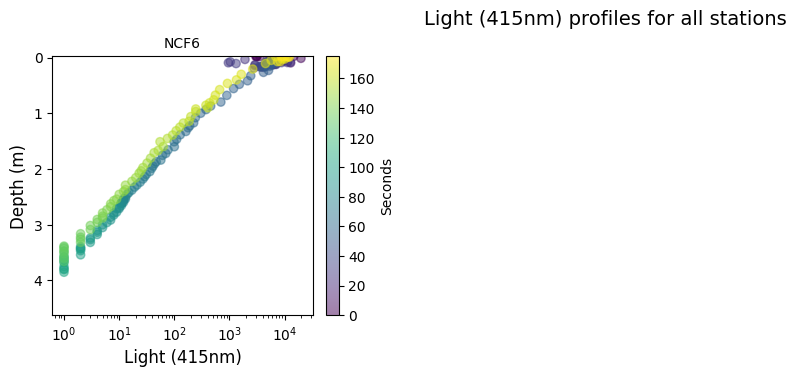

In [17]:
# 415nm panels for all stations 
if len(all_data) > 0:
    # preserve the original cast order from the loaded files
    ordered = list(all_data.keys())

    num = len(ordered)

    # Use fixed 3x4 rectangular layout to match script 1
    nrows, ncols = 3, 4

    # use the deepest cast depth as the shared y-range for all stations
    # this makes every subplot comparable on the same vertical scale
    global_min_depth = min(np.min(data['Depth_SS_L']) for data in all_data.values())
    global_max_depth = max(np.max(data['Depth_SS_L']) for data in all_data.values())

    # create a grid of subplot axes
    fig, axs = plt.subplots(nrows, ncols, figsize=(12, 9), constrained_layout=True, sharey=False)
    axs = np.array(axs).reshape(-1)

    # Plot as many stations as we have room for (up to 12 panels)
    max_panels = nrows * ncols
    for idx, fn in enumerate(ordered[:max_panels]):
        data = all_data[fn]
        ax = axs[idx]

        # plot each cast in the preferred order
        im = ax.scatter(data['E415nm_SS'], data['Depth_SS_L'], c=data['DATA_SEC0'], marker='o', alpha=0.5)

        # extract station label from the filename, e.g. (NC11) or (ACME)
        mobj = re.search(r"\(([^)]+)\)", fn)
        station = mobj.group(1) if mobj else fn
        ax.set_title(station, fontsize=10)
        ax.set_xlabel('Light (415nm)', fontsize=12)
        ax.set_ylabel('Depth (m)', fontsize=12)
        ax.set_xscale('log')

        # use the same depth limits for every subplot so the y-axis is consistent
        ax.set_ylim([global_max_depth, global_min_depth])
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label('Seconds')

    # hide any unused subplot axes in the grid
    for ax in axs[num:max_panels]:
        ax.set_visible(False)

    if num > max_panels:
        print(f"Showing first {max_panels} stations out of {num} total.")

    fig.suptitle('Light (415nm) profiles for all stations', fontsize=14)
    plt.show()
else:
    print("No data available to plot 415nm profiles.")

In [18]:
# Kd analysis: Helper functions for spectral diffuse attenuation coefficient

def compute_kd_for_wavelength(E_data, depth_data):
    """
    Core Kd computation for a single irradiance array.
    Filters valid data, normalizes by surface irradiance, and fits ln(E/E0) = -Kd*depth.
    Returns: (Kd_value, R_squared) or (None, None) if insufficient valid data
    """
    # Filter: positive irradiance, valid finite numbers, depth ≥ 0
    valid_idx = (E_data > 0) & np.isfinite(E_data) & (depth_data >= 0)
    
    # Only regress if we have sufficient valid samples (>10 points)
    if np.sum(valid_idx) > 10:
        # Normalize by surface irradiance (E at minimum depth)
        E0 = E_data[np.argmin(depth_data)]
        ln_E = np.log(E_data[valid_idx] / E0)
        
        # Fit: ln(E/E0) = -Kd * depth  =>  slope = -Kd
        slope, _, r_value, _, _ = linregress(depth_data[valid_idx], ln_E)
        return -slope, r_value**2
    
    return None, None


def compute_kd_spectrum(data):
    """
    Compute Kd spectrum (absorption coefficient vs wavelength) for all 8 spectral bands.
    Uses logarithmic regression: ln(E) = -Kd*depth, where Kd = -slope
    Returns: (Kd_values, wavelengths_Kd, R_squared)
    """
    # Pair each irradiance array with its nominal wavelength
    irradiance_data = [
        (data['E415nm_SS'], 415),
        (data['E445nm_SS'], 445),
        (data['E480nm_SS'], 480),
        (data['E515nm_SS'], 515),
        (data['E555nm_SS'], 555),
        (data['E590nm_SS'], 590),
        (data['E630nm_SS'], 630),
        (data['E680nm_SS'], 680),
    ]
    Kd_values, wavelengths_Kd, R_squared = [], [], []
    
    for E_data, wl in irradiance_data:
        kd, r2 = compute_kd_for_wavelength(E_data, data['Depth_SS_L'])
        if kd is not None:
            Kd_values.append(kd)
            wavelengths_Kd.append(wl)
            R_squared.append(r2)
    
    return Kd_values, wavelengths_Kd, R_squared


def compute_kd_at_wavelength(data, target_wl):
    """
    Compute Kd at a single target wavelength.
    Returns: (Kd_value, R_squared) or (None, None) if wavelength not available or insufficient data
    """
    # Map wavelength to irradiance array
    irradiance_map = {
        415: data['E415nm_SS'],
        445: data['E445nm_SS'],
        480: data['E480nm_SS'],
        515: data['E515nm_SS'],
        555: data['E555nm_SS'],
        590: data['E590nm_SS'],
        630: data['E630nm_SS'],
        680: data['E680nm_SS'],
    }
    
    E_data = irradiance_map.get(target_wl)
    if E_data is None:
        return None, None
    
    return compute_kd_for_wavelength(E_data, data['Depth_SS_L'])


260716-07(NCF6)-A017.txt:
  Kd(415 nm) = 2.449 m^-1  (R² = 0.981)
  Kd(445 nm) = 2.515 m^-1  (R² = 0.970)
  Kd(480 nm) = 2.804 m^-1  (R² = 0.984)
  Kd(515 nm) = 2.627 m^-1  (R² = 0.990)
  Kd(555 nm) = 2.272 m^-1  (R² = 0.992)
  Kd(590 nm) = 2.075 m^-1  (R² = 0.991)
  Kd(630 nm) = 1.970 m^-1  (R² = 0.990)
  Kd(680 nm) = 1.934 m^-1  (R² = 0.990)


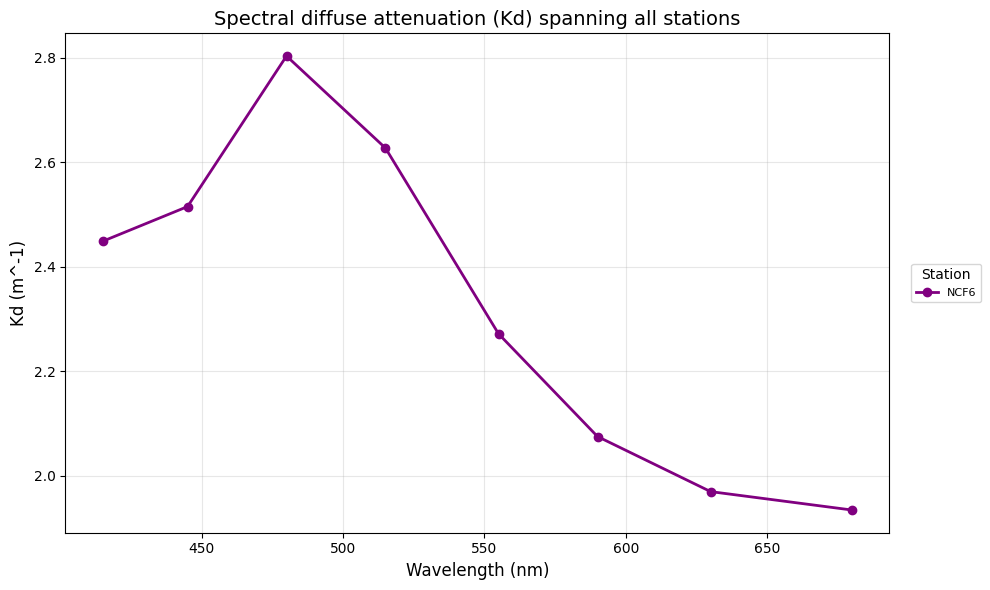

In [19]:
# Compare Kd spectra from all casts
if len(all_data) > 0:
    plt.figure(figsize=(10, 6))
    
    # Create a custom colormap gradient: purple → yellow → green
    from matplotlib.colors import LinearSegmentedColormap
    colors_list = ['purple', 'yellow', 'green']
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list('purple_yellow_green', colors_list, N=n_bins)
    
    # Get number of files to normalize the color gradient
    num_files = len(all_data)
    
    for idx, (filename, data) in enumerate(all_data.items()):
        Kd_values, wavelengths_Kd, R_squared = compute_kd_spectrum(data)
        if len(wavelengths_Kd) > 0:
            # Sort by wavelength
            sorted_idx = np.argsort(wavelengths_Kd)
            wl_sorted = np.array(wavelengths_Kd)[sorted_idx]
            kd_sorted = np.array(Kd_values)[sorted_idx]
            
            # Map day index to color gradient (0 to 1)
            color_pos = idx / (num_files - 1) if num_files > 1 else 0
            color = cmap(color_pos)
            
            # Extract station name from filename (format: YYMMDD-xx(STATION)-AXXX.txt)
            mobj = re.search(r"\(([^)]+)\)", filename)
            station = mobj.group(1) if mobj else filename
            plt.plot(wl_sorted, kd_sorted, 'o-', color=color, label=station, linewidth=2)
            
            # Print Kd values
            print(f"\n{filename}:")
            for wl, kd, r2 in zip(wavelengths_Kd, Kd_values, R_squared):
                print(f"  Kd({wl:3d} nm) = {kd:.3f} m^-1  (R² = {r2:.3f})")
    
    plt.xlabel('Wavelength (nm)', fontsize=12)
    plt.ylabel('Kd (m^-1)', fontsize=12)
    plt.title('Spectral diffuse attenuation (Kd) spanning all stations', fontsize=14)
    plt.legend(fontsize=8, title='Station', title_fontsize=10, loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

260716-07(NCF6)-A017.txt: Kd(415 nm) = 2.449 | start 13:36:30 EST


/var/folders/sx/lycmz0mx4qv7m5v2s05gwh100000gn/T/ipykernel_16593/2271425055.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10').colors


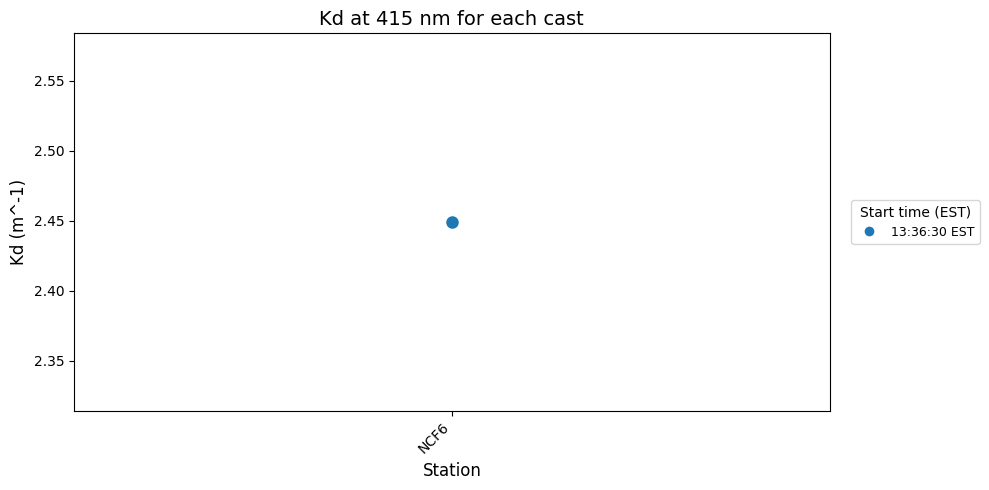

In [20]:
import re
from matplotlib.lines import Line2D

target_wl = 415
start_times = []
kd_values = []
labels = []

num_files = len(all_data)

for idx, (filename, data) in enumerate(all_data.items()):
    kd, r2 = compute_kd_at_wavelength(data, target_wl)
    if kd is not None:

        # convert first time entry (UTC) to EST by subtracting 4 hours
        t0 = data['Time_SS'][0]
        try:
            h, m, s = map(int, t0.split(':'))
            h_est = (h - 4) % 24
            t_est = f"{h_est:02d}:{m:02d}:{s:02d} EST"
        except Exception:
            t_est = t0

        # station code from parentheses
        mobj = re.search(r"\(([^)]+)\)", filename)
        station = mobj.group(1) if mobj else filename

        start_times.append(t_est)
        kd_values.append(kd)
        labels.append(f"{station} — {t_est}")
        print(f"{filename}: Kd({target_wl} nm) = {kd:.3f} | start {t_est}")

if kd_values:
    plt.figure(figsize=(10, 5))
    # get list of colors from colormap
    colors = plt.cm.get_cmap('tab10').colors

    # plot individual points and connecting line
    for i, (kd, col) in enumerate(zip(kd_values, colors)):
        plt.plot(i, kd, 'o', color=col, markersize=8)
    plt.plot(range(len(kd_values)), kd_values, '-', color='gray', alpha=0.5)

    station_names = [lab.split(' — ')[0] for lab in labels]
    start_time_labels = [lab.split(' — ')[1] for lab in labels]

    plt.xlabel('Station', fontsize=12)
    plt.ylabel('Kd (m^-1)', fontsize=12)
    plt.title(f'Kd at {target_wl} nm for each cast', fontsize=14)
    plt.xticks(range(len(station_names)), station_names, rotation=45, ha='right')

    # legend on the right showing cast start times in EST
    handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], markersize=8) for i in range(len(labels))]
    plt.legend(handles, start_time_labels, title='Start time (EST)', bbox_to_anchor=(1.02, 0.5), loc='center left', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print(f"No Kd values found at {target_wl} nm.")
